# A simple causal discovery and inference pipeline using simulated data with known causal influences

## Notebook outline

The notebook runs through the following:

1. Package installs
2. Create synthetic data with known causal relationships
3. Identify a DAG using Peter-Clarke algorithm
4. Formalise the output of the DAG
5. Measure average treatment effects (ATE) with Linear Double Machine Learning
6. Measure conditional average treatment effects with Causal Forest

---

## 1. Package installs

Standard packages use are numpy, pandas, matplotlib, scikit-learn

For specialist packages, run the following code cell (currently commented out):

In [1]:
# !pip install causallearn dowhy econml networkx pydot graphviz

In [2]:
# Import general packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydot
import networkx as nx
from networkx.algorithms.d_separation import is_d_separator

# Import causal-learn packages for causal discovery
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

# Import Causal Forest packages for causal inference (conditional average treatment effecs)
from dowhy import CausalModel
from econml.grf import CausalForest
from econml.dml import CausalForestDML # Causal forest with double machine learning
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

---

## 2 Create synthetic data with known causal relationships

Data is simulated to mimic stroke patients, treatment, and outcomes

* *Patient characteristics*: age, ethnicity, sex, use of warfarin, stroke severity, shoe size
* *Outcome*: death
* *Treatment*: thrombolysis (a clot-busting treatment aimed at dissolving the clot causing the stroke)

### Rules for synthetic data

Synthetic data based on:

POPULATION:

* Patients are aged 60-95, uniformly distrIbuted
* Ethnicity is 70% white, 20% asian, 10% black
* Patients are split 50:50 male:female
* Stroke severity (NIHSS) has triangular distrubution ranging from 0 to 30
* Shoe_size is set to add noise to data (they have no effect)

MORTALITY:

* Baseline mortality is 10%
* Mortality increases by 1 percentage point every year above age 60
* Mortality increases 10 percentage points for males
* Morrtality increases 1 percentage points for each NIHSS unit

THROMBOLYSIS USE:

* Baseline thrombolysis treatment is 20%
* Thrombolysis rate is reduced 5% for asian patients and 10% for black patients
* Thrombolysis rate is halved if aged more than 80
* No thrombolysis use for NIHSS <5; thrombolysis use declines to zero between NIHSS 20 and 30

THROMBOLYSIS EFFICACY

* The baseline effect of use of thrombolysis is to halve mortality
* Thrombolysis is half as effective in asian and black people
* Thrombolysis is half as effective if aged 80%
* The effectiveness climbs between NIHSS 5 and 10, is stable NIHSS 10-20 and declines to zero between 20 and 30.

In [3]:
np.random.seed(42)
N = 50_000

# ──── Make synthetic data ────

# --- Demographics
age = np.random.randint(60, 96, size=N)
ethnicity = np.random.choice(['white', 'asian', 'black'], size=N, p=[0.70, 0.20, 0.10])
male = np.random.randint(0, 2, size=N)

# --- Warfarin (20% prevalence) ---
warfarin = np.random.binomial(1, 0.20, size=N)

# --- Noise variables (no causal role) ---
shoe_size = np.random.triangular(5, 9, 13, size=N).astype(int)

# --- NIHSS stroke severity (triangular distribution, 0–30, mode 10) ---
nihss = np.random.triangular(0, 10, 30, size=N).astype(int)

# NIHSS determines:
#   - eligibility/probability of thrombolysis (zero below 5, ramps 5-10, 
#   - stable 10-20, ramps down 20-30)
#   - effectiveness of thrombolysis (same shape)
#   - baseline mortality risk (linear increase with severity)

def nihss_weight(n):
    """Returns a 0–1 weight encoding the NIHSS-driven treatment/effect profile."""
    if n < 5:
        return 0.0
    elif n < 10:
        return (n - 5) / 5.0
    elif n <= 20:
        return 1.0
    elif n <= 30:
        return (30 - n) / 10.0
    else:
        return 0.0

nihss_wt = np.array([nihss_weight(n) for n in nihss])

# --- Thrombolysis probability ---
thrombolysis_prob = np.full(N, 0.20)
thrombolysis_prob[ethnicity == 'asian'] -= 0.05
thrombolysis_prob[ethnicity == 'black'] -= 0.10
thrombolysis_prob[age > 80] /= 2
thrombolysis_prob[warfarin == 1] *= 0.10
thrombolysis_prob *= nihss_wt
thrombolysis_prob = np.clip(thrombolysis_prob, 0, 1)

thrombolysis = np.random.binomial(1, thrombolysis_prob)

# --- Mortality probability ---
mortality_prob = np.full(N, 0.10)
mortality_prob += (age - 60) * 0.01
mortality_prob[male == 1] += 0.10
mortality_prob += nihss * 0.01
mortality_prob = np.clip(mortality_prob, 0, 1)

# --- Thrombolysis effect on mortality ---
# Demographic modifiers (same as v1):
#   - Both age>80 AND non-white: multiplier 0.875 (reduction halved twice)
#   - Either alone:              multiplier 0.75  (reduction halved once)
#   - Neither:                   multiplier 0.5   (full 50% reduction)
# NIHSS scales the reduction: multiplier = 1 - (1 - base_mult) * nihss_wt
# When nihss_wt=0 → no effect; nihss_wt=1 → full demographic-adjusted effect
reduced_effectiveness = (ethnicity == "asian") | (ethnicity == "black")
age_over_80_treated = (thrombolysis == 1) & (age > 80)
ethnicity_reduced   = (thrombolysis == 1) & reduced_effectiveness
both = age_over_80_treated & ethnicity_reduced

base_multiplier = np.where(both, 0.875,
    np.where(age_over_80_treated | ethnicity_reduced, 0.75, 0.5))

nihss_scaled_multiplier = 1.0 - (1.0 - base_multiplier) * nihss_wt
thrombolysis_effect = np.where(thrombolysis == 0, 1.0, nihss_scaled_multiplier)

mortality_prob *= thrombolysis_effect
mortality_prob = np.clip(mortality_prob, 0, 1)

died = np.random.binomial(1, mortality_prob)

# --- DataFrame ---
df = pd.DataFrame({
    "patient_id":         np.arange(1, N + 1),
    "age":                age,
    "ethnicity":          ethnicity,
    "male":               male,
    "warfarin":           warfarin,
    "shoe_size":          shoe_size,
    "nihss":              nihss,
    "thrombolysis_prob":  np.round(thrombolysis_prob, 4),
    "thrombolysis":       thrombolysis,
    "mortality_prob":     np.round(mortality_prob, 4),
    "died":               died,
})

# ──── Compute TRUE treatment effects from data-generating process ────

# Reconstruct potential outcome under treatment for every patient
mortality_base = np.full(N, 0.10)
mortality_base += (df["age"].values - 60) * 0.01
mortality_base[df["ethnicity"] == "asian"] += 0.05
mortality_base[df["ethnicity"] == "black"] += 0.10
mortality_base[df["male"] == 1] += 0.10
mortality_base += df["nihss"].values * 0.01
mortality_base = np.clip(mortality_base, 0, 1)

nihss_wt_all = np.array([nihss_weight(n) for n in df["nihss"].values])
reduced_eff_all = (df["ethnicity"] == "asian") | (df["ethnicity"] == "black")
age_over_80_all = df["age"].values > 80
both_all        = age_over_80_all & reduced_eff_all.values

base_mult_all = np.where(both_all, 0.875,
    np.where(age_over_80_all | reduced_eff_all.values, 0.75, 0.5))

true_tx_multiplier = 1.0 - (1.0 - base_mult_all) * nihss_wt_all
mortality_treated  = np.clip(mortality_base * true_tx_multiplier, 0, 1)

# True CATE = E[Y(1)] – E[Y(0)]; negative = treatment reduces mortality
true_cate = mortality_treated - mortality_base
df["true_cate"] = np.round(true_cate, 6)

# ──── Save (if necessary)────
#df.to_csv("synthetic_stroke_data.csv", index=False)
#print("Saved synthetic_stroke_data.csv:", df.shape)

---

## 2. Identify causal relationships using causallearn.search.ConstraintBased.PC

The `causallearn.search.ConstraintBased.PC` function is an implementation of the Peter-Clark (PC) algorithm in the `causal-learn` Python library. As a constraint-based causal discovery method, the PC algorithm uses conditional independence tests on observational data to identify causal relationships, returning a Directed Acyclic Graph (DAG) or Partially Directed Acyclic Graph (CPDAG). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The algorithm systematically prunes a fully connected network into a sparse graph based on statistical evidence, assuming there are no unmeasured (latent) confounders. [lmyint.github](https://lmyint.github.io/causal_spring_2020/causal-discovery.html)

### 1. Skeleton Discovery (Adjacency Search)
The PC algorithm begins with a fully connected graph containing all observed variables. It iteratively removes edges by testing for conditional independence. First, it tests all pairs of variables for marginal (unconditional) independence, removing edges where no association is found. It then tests remaining adjacent variables for conditional independence given subsets of size 1, then size 2, increasing the subset size systematically. If $X$ and $Y$ are found to be conditionally independent given a subset $Z$, the edge between them is deleted, and $Z$ is recorded as the "separation set" (sepset) for that pair. [jmlr](https://jmlr.org/papers/volume15/colombo14a/colombo14a.pdf)

### 2. Collider Orientation (v-structures)
Once the skeleton is finalized, the algorithm looks for unshielded triples—patterns where variable $X$ is connected to $Y$, and $Y$ is connected to $Z$, but $X$ and $Z$ are not connected. For each unshielded triple $X - Y - Z$, it checks the sepset recorded when the edge between $X$ and $Z$ was deleted. If $Y$ is *not* in that sepset, the algorithm orients the edges toward $Y$ to form a collider (v-structure): $X \rightarrow Y \leftarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### 3. Edge Orientation Rules
After identifying all colliders, the algorithm applies a set of logical rules (Meek rules) to orient as many remaining undirected edges as possible without creating new colliders or cycles. For example, if it finds $X \rightarrow Y - Z$ and orienting $Y \leftarrow Z$ would create a new collider that wasn't identified in step 2, it logically forces the orientation $Y \rightarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### Python Implementation and Parameters
In `causal-learn`, the `pc()` function is called with the dataset (a NumPy array) and allows for several key configurations: [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `alpha`: The significance level for the conditional independence tests (default 0.05). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `indep_test`: The statistical test used, such as Fisher's Z (`fisherz`) for linear continuous data, Chi-squared for discrete data, or Kernel-based (`kci`) for non-linear continuous data. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `uc_rule` and `uc_priority`: Define how the algorithm handles conflicting unshielded colliders, offering options like maxP (orienting based on additional CI tests) to improve robustness. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `mvpc`: Allows the algorithm to handle missing values natively. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The function returns a `CausalGraph` object (`cg`), where `cg.G.graph` contains the final adjacency matrix representing the discovered causal relationships. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

  0%|          | 0/8 [00:00<?, ?it/s]

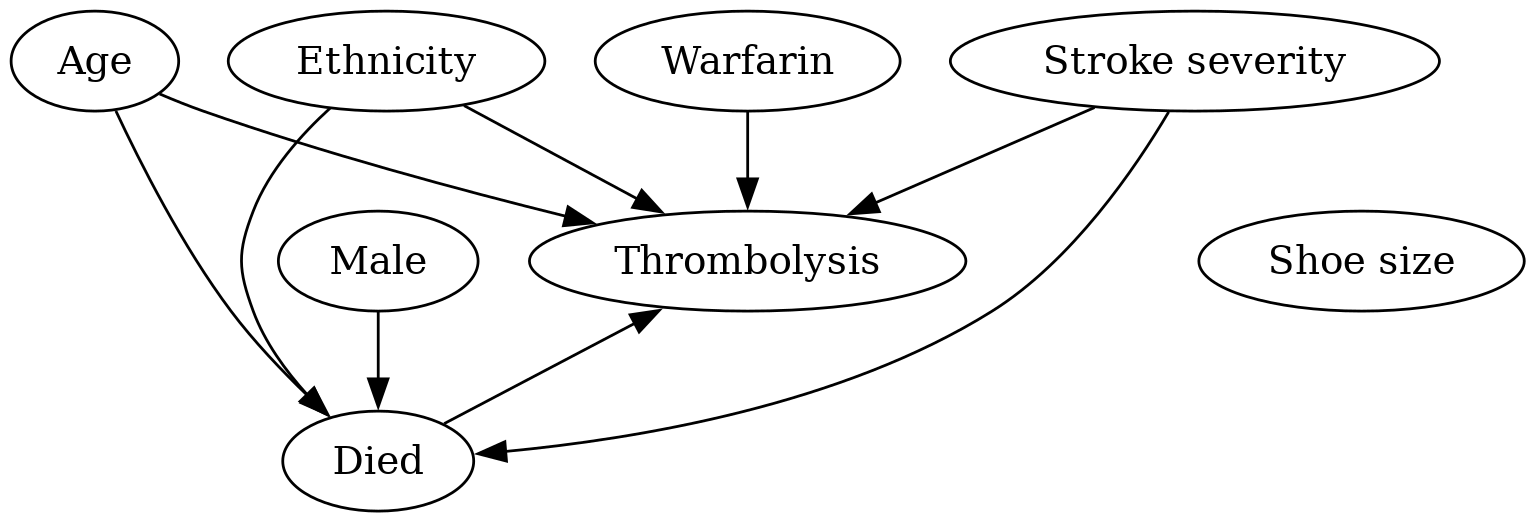

In [4]:
# --- Preprocessing ---
# 1. Map ethnicity to numeric values for the algorithm
ethnicity_map = {'white': 0, 'asian': 1, 'black': 2}
df['ethnicity_idx'] = df['ethnicity'].map(ethnicity_map)

# 2. Select only the features relevant to the causal structure
feature_cols = [
    'age', 'ethnicity_idx', 'male', 'thrombolysis', 'nihss', 'warfarin', 'shoe_size', 'died']
data_for_pc = df[feature_cols].to_numpy()

# Define the labels in the same order as feature_cols
node_names = [
    'Age', 'Ethnicity', 'Male', 'Thrombolysis', 'Stroke severity', 'Warfarin', 'Shoe size', 'Died']

# Run PC with names, alpha=0.05 is the significance level for independence tests
cg = pc(data_for_pc, alpha=0.05, node_names=node_names)

# --- Visualization using Graphviz ---
# 1. Generate the initial pydot graph
pyd = GraphUtils.to_pydot(cg.G)

# 2. Create a subgraph that forces its contents to the bottom
sink_subgraph = pydot.Subgraph(rank='sink')

# 3. Find the 'died' node and add it to the sink subgraph
for node in pyd.get_nodes():
    if 'Died' in str(node.get_name()) or 'Died' in str(node.get_label()):
        sink_subgraph.add_node(pydot.Node(node.get_name()))
        break

# 4. Add the subgraph back to the main graph
pyd.add_subgraph(sink_subgraph)

# 5. Save the modified graph
pyd.write_png('./output/stroke_causal_dag.png')

# To display directly in a Jupyter Notebook:
from IPython.display import Image
Image('./output/stroke_causal_dag.png')

---

## 3. Define causal model (Formalise the output of the DAG)

This Python code is using the `dowhy` library (specifically its `CausalModel` class) to define and analyze a causal inference problem. It represents the first two steps of the standard DoWhy workflow: **Modeling** and **Identification**. [datacamp](https://www.datacamp.com/tutorial/intro-to-causal-ai-using-the-dowhy-library-in-python)

Here is what is happening step-by-step:

### a. Defining the Causal Model
The `CausalModel` block creates an explicit map of the assumptions you are making about your data:
- `data=df`: You are passing in a pandas DataFrame (`df`) containing your observational data.
- `treatment='thrombolysis'`: You are specifying that "thrombolysis" is the intervention or cause you want to study.
- `outcome='died'`: You are specifying that "died" (mortality) is the effect you want to measure.
- `common_causes=['age', 'ethnicity_idx', 'male']`: These are the confounding variables (variables that affect *both* whether a patient receives thrombolysis and their risk of dying). You are telling the model it must adjust for these to prevent biased results. [perplexity](https://www.perplexity.ai/search/e57c770c-88dd-4e89-87ac-3fbbbaac2dd6)
- `effect_modifiers=['age', 'ethnicity_idx']`: These are variables that don't necessarily cause the treatment, but they change *how effective* the treatment is. By specifying these, you are preparing the model to calculate Conditional Average Treatment Effects (CATE), allowing you to see how thrombolysis works differently for different age groups or ethnicities. [perplexity](https://www.perplexity.ai/search/e1b532f7-38b1-406e-95f0-f02e1117bea1)

### b. Identifying the Causal Effect (`identify_effect`)
The line `identified_estimand = model.identify_effect(...)` asks the DoWhy library to look at the causal model you just defined and determine the mathematical recipe (the "estimand") required to isolate the true causal effect from the data. [causalwizard](https://causalwizard.app/inference/article/identification)
- It uses the rules of causal graphs (like Pearl's *do*-calculus or backdoor criteria) to translate the causal question ("What happens if we *force* thrombolysis?") into a statistical formula that can be calculated using purely observational data. [pywhy](https://www.pywhy.org/dowhy/v0.14/user_guide/causal_tasks/estimating_causal_effects/identifying_causal_effect/index.html)
- The argument `proceed_when_unidentifiable=True` tells the algorithm to push forward and return an estimand even if it detects that some assumptions are violated or unmeasured confounders might prevent a perfect mathematical identification.

Output is given as:

* Estimand 1: backdoor - uses backdoor method defined by Pearl
* Estimand 2: instrument variable (IV)
* Estimand 3: frontdoor - uses frontdoor method defined by Pearl
*  Estimand 4: general adjustment. This is a generalized version of covariate adjustment that often mirrors the backdoor set in standard causal DAGs

* "No such variable(s) found!" mean that the method did not find a valid set of variables to adjust for using that method.


In [5]:
model = CausalModel(
    data=df,
    treatment='thrombolysis',
    outcome='died',
    common_causes=['age', 'ethnicity_idx', 'male', 'nihss'],
    effect_modifiers=['age', 'ethnicity_idx', 'nihss']
)

# Compatibility patch: DoWhy expects nx.algorithms.d_separated in some versions
if not hasattr(nx.algorithms, "d_separated"):
    def d_separated(G, X, Y, Z):
        return is_d_separator(G, set(X), set(Y), set(Z))
    nx.algorithms.d_separated = d_separated


identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified Estimand:\n", identified_estimand)

# 'U' is unmeasured confounders

Identified Estimand:
 Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                             
───────────────(E[died|ethnicity_idx,age,male,nihss])
d[thrombolysis]                                      
Estimand assumption 1, Unconfoundedness: If U→{thrombolysis} and U→died then P(died|thrombolysis,ethnicity_idx,age,male,nihss,U) = P(died|thrombolysis,ethnicity_idx,age,male,nihss)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                             
───────────────(E[died|ethnicity_idx,age,male,nihss])
d[thrombolysis]                                      
Estimand assumption 1, Unconfoundedness: If U→{thrombolysis} and U→died then P(died|thrombolysis,ethnicity_idx,age,male,nihss,U) = P(died|thrombolysis,ethnici

---

## 4. Measure average treatment effects

This section uses the `dowhy` library paired with Microsoft's `econml` library to estimate the ATE using only the observable data. [pywhy](https://www.pywhy.org/dowhy/v0.10.1/example_notebooks/dowhy-conditional-treatment-effects.html)

It uses a specific technique called **Double Machine Learning (DML)** (`LinearDML`): [pywhy](https://www.pywhy.org/dowhy/v0.10.1/example_notebooks/dowhy-conditional-treatment-effects.html)
- **`model_y`**: A Random Forest Classifier is used to predict the outcome (mortality) based on patient characteristics.
- **`model_t`**: A second Random Forest Classifier is used to predict who gets the treatment (thrombolysis) based on patient characteristics (this is the propensity score). [perplexity](https://www.perplexity.ai/search/521b3429-2f7a-4d8e-865f-c88473867261)
- The `LinearDML` algorithm takes the residual errors from both of these Random Forest models and mathematically combines them to isolate the pure causal effect of the treatment on the outcome, stripping away the confounding variables (like age and ethnicity).

In [6]:
# Print actual treatment effect 
# Since our true CATE is already computed in the DataFrame, we can calculate the average true effect across the entire dataset:
true_ate = df['true_cate'].mean()
print("True ATE:", true_ate)

# Calculate and show calulated ATE using the backdoor method with EconML's LinearDML

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": RandomForestClassifier(n_estimators=200, random_state=42),
            "model_t": RandomForestClassifier(n_estimators=200, random_state=42),
            "discrete_treatment": True,
            "discrete_outcome": True,
            "random_state": 42,
        },
        "fit_params": {}
    }
)

print("Estimated ATE:", estimate.value)

True ATE: -0.1115321675
Estimated ATE: [-0.12995179]


---

## 5. Measure conditional average treatment effects with a Causal Forest

**Causal forests** are a way of comparing similar people who did and did not get a treatment, to work out how much the treatment actually helps different kinds of people. They repeatedly split people into many small, similar groups (like little ‘branches’ on a tree), then compare outcomes for treated versus untreated people inside each group. By growing many such trees and averaging their answers, causal forests give a more reliable estimate of ‘how much this treatment helps someone like you’ than any single model alone.

In [7]:
# ─── Encode ethnicity as dummy variables ───
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['ethnicity'], drop_first=False)

feature_cols = ['age', 'male', 'nihss',
                'ethnicity_asian', 'ethnicity_black', 'ethnicity_white']

X = df_model[feature_cols].values.astype(float)
T = df_model['thrombolysis'].values.astype(float)
Y = df_model['died'].values.astype(float)

# ─── Fit Causal Forest ───
cf = CausalForest(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=25,
    random_state=42,
)

# Note the updated positional argument order: X, T, Y
cf.fit(X, T, Y)

# ── Estimate CATE ──
# Use predict() instead of effect() for grf.CausalForest
estimated_cate = cf.predict(X).flatten()
df['estimated_cate'] = estimated_cate

# Add error column for analysis
df['cate_error'] = df['estimated_cate'] - df['true_cate']
absolute_error_mean = df['cate_error'].abs().mean()
print(f"\nAverage absolute error in CATE estimates: {absolute_error_mean:.4f}")

# ── NIHSS subgroup masks ──
nihss_subgroups = [
    ('NIHSS <10',   df['nihss'] < 10),
    ('NIHSS 10-20', (df['nihss'] >= 10) & (df['nihss'] <= 20)),
    ('NIHSS >20',   df['nihss'] > 20),
]

# ── Summary by subgroup ───
print("=== Average CATE by Subgroup ===\n")

# By ethnicity
for eth in ['white', 'asian', 'black']:
    mask = df['ethnicity'] == eth
    print(f"Ethnicity={eth:5s}  True CATE: {df.loc[mask,'true_cate'].mean():+.4f}  "
          f"Estimated CATE: {df.loc[mask,'estimated_cate'].mean():+.4f}")

# By age group
for label, mask in [('Age <=80', df['age'] <= 80), ('Age >80', df['age'] > 80)]:
    print(f"{label:10s}  True CATE: {df.loc[mask,'true_cate'].mean():+.4f}  "
          f"Estimated CATE: {df.loc[mask,'estimated_cate'].mean():+.4f}")

# By NIHSS subgroup
for label, mask in nihss_subgroups:
    print(f"{label:12s}  True CATE: {df.loc[mask,'true_cate'].mean():+.4f}  "
          f"Estimated CATE: {df.loc[mask,'estimated_cate'].mean():+.4f}")

print(f"\nOverall ATE  True CATE: {df['true_cate'].mean():+.4f}  "
      f"Estimated CATE: {df['estimated_cate'].mean():+.4f}")


Average absolute error in CATE estimates: 0.0582
=== Average CATE by Subgroup ===

Ethnicity=white  True CATE: -0.1281  Estimated CATE: -0.1317
Ethnicity=asian  True CATE: -0.0711  Estimated CATE: -0.1022
Ethnicity=black  True CATE: -0.0781  Estimated CATE: -0.0976
Age <=80    True CATE: -0.1261  Estimated CATE: -0.1233
Age >80     True CATE: -0.0911  Estimated CATE: -0.1209
NIHSS <10     True CATE: -0.0442  Estimated CATE: -0.0649
NIHSS 10-20   True CATE: -0.1519  Estimated CATE: -0.1490
NIHSS >20     True CATE: -0.1170  Estimated CATE: -0.1574

Overall ATE  True CATE: -0.1115  Estimated CATE: -0.1223


Plot results:

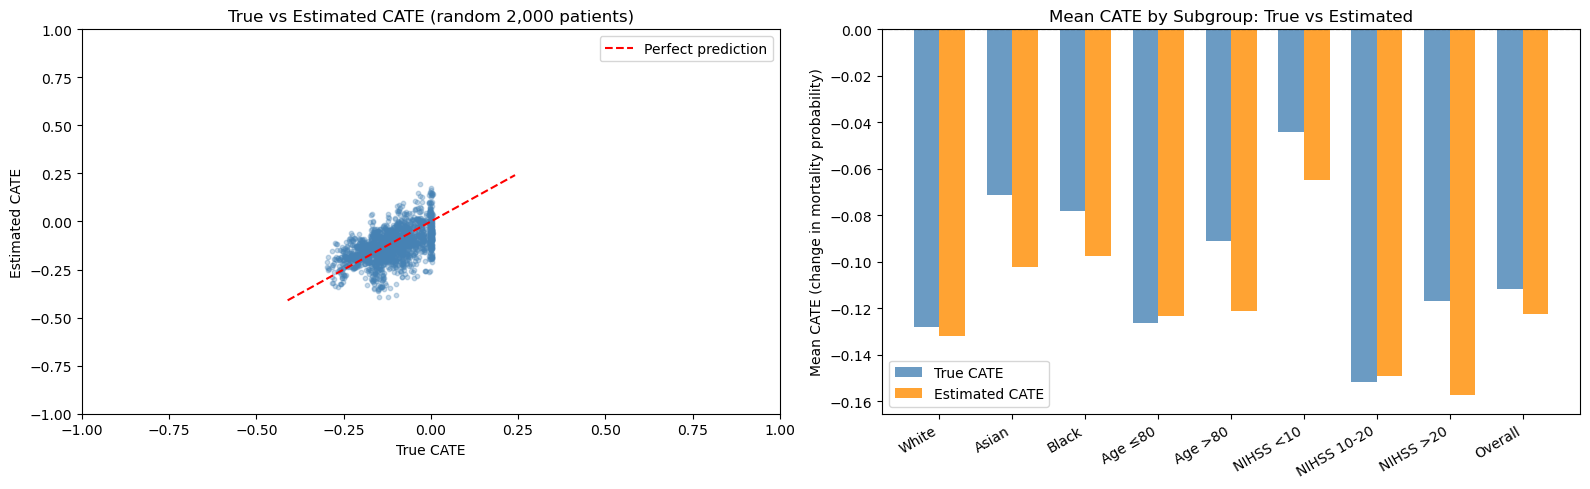

In [8]:
# ── Scatter: true vs estimated CATE (sample 2000 pts for clarity) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: scatter true vs estimated
sample = df.sample(2000, random_state=42)
rng = np.random.default_rng(42)
x_jitter = sample['true_cate'].to_numpy() + rng.uniform(-0.005, 0.005, size=len(sample))
y_jitter = sample['estimated_cate'].to_numpy() + rng.uniform(-0.005, 0.005, size=len(sample))

axes[0].set_xlim(-1.0, 1.0)
axes[0].set_ylim(-1.0, 1.0)

axes[0].scatter(x_jitter, y_jitter, alpha=0.3, s=10, color='steelblue')
lims = [min(df['true_cate'].min(), df['estimated_cate'].min()) - 0.01,
        max(df['true_cate'].max(), df['estimated_cate'].max()) + 0.01]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True CATE')
axes[0].set_ylabel('Estimated CATE')
axes[0].set_title('True vs Estimated CATE (random 2,000 patients)')
axes[0].legend()

# Right: mean CATE by subgroup comparison
subgroups = [
    'White', 'Asian', 'Black',
    'Age ≤80', 'Age >80',
    'NIHSS <10', 'NIHSS 10-20', 'NIHSS >20',
    'Overall'
]
masks = [
    df['ethnicity'] == 'white',
    df['ethnicity'] == 'asian',
    df['ethnicity'] == 'black',
    df['age'] <= 80,
    df['age'] > 80,
    df['nihss'] < 10,
    (df['nihss'] >= 10) & (df['nihss'] <= 20),
    df['nihss'] > 20,
    pd.Series([True] * len(df)),
]
true_means = [df.loc[m, 'true_cate'].mean() for m in masks]
est_means  = [df.loc[m, 'estimated_cate'].mean() for m in masks]

x = np.arange(len(subgroups))
w = 0.35
axes[1].bar(x - w/2, true_means, w, label='True CATE', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, est_means,  w, label='Estimated CATE', color='darkorange', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(subgroups, rotation=30, ha='right')
axes[1].set_ylabel('Mean CATE (change in mortality probability)')
axes[1].set_title('Mean CATE by Subgroup: True vs Estimated')
axes[1].legend()

plt.tight_layout()
plt.show()